# Chapter 6: Capital Asset Pricing Model

This atlas follows the lecture sequence and uses deterministic financial data so
that every code module can run without an internet connection.

## Learning map

1. Simple linear regression
2. CAPM alpha and beta
3. Merging asset and market returns
4. Statistical significance of beta
5. Rolling beta and portfolio beta

**Code availability:** Yes. Every code cell imports its own dependencies,
contains Chinese exam-oriented comments, and produces an interpretable result.

## How to Study This Chapter

- **First pass:** Read the concept and formula sections without running code.
- **Second pass:** Predict the output and fill in the commented key lines before execution.
- **Third pass:** Run each module independently and explain the result in one sentence.
- **Final review:** Compare related methods and identify when each method should or should not be used.

## Chapter Checklist

- Can I define every variable and state its unit?
- Can I reproduce the main formula or workflow without looking?
- Can I identify the code lines most likely to appear as blanks?
- Can I interpret the output economically or statistically?
- Can I name at least one common implementation error?


## 6.1 Simple Linear Regression

A one-factor model is $y=\alpha+\beta x+\epsilon$. The slope measures the change in the dependent variable associated with a one-unit change in the factor.


### Structured Review

- **Dependent variable:** Asset return or asset excess return belongs on the left-hand side.
- **Independent variable:** Market return or market excess return explains the asset.
- **Intercept:** A constant column is required when alpha is estimated.
- **Alignment:** Join datasets by matching dates before running the regression.

### Interpretation

- `alpha` measures the intercept or abnormal return.
- `beta` measures sensitivity to the market factor.
- `R-squared` measures the proportion of sample variation explained by the model.
- A p-value evaluates statistical significance, not economic size.

### Exam Focus

- Preserve the order `x = market`, `y = stock`.
- Add a constant before OLS.
- Read the beta from the market coefficient, not the intercept.

### Common Mistakes

- Reversing stock and market inputs in `linregress`.
- Merging unmatched dates without checking missing values.
- Treating a high beta as proof of a high realized return.


In [1]:
'''
本单元使用矩阵公式估计多元线性回归，避免依赖特定回归软件。
X 第一列加入常数 1，对应回归截距 alpha。
'''
import numpy as np

rng = np.random.default_rng(300 + 1)
n = 360
factor_names = ['Market']
factors = rng.normal(0, 0.01, (n, len(factor_names)))
true_betas = np.linspace(1.10, 0.25, len(factor_names))
asset_excess_return = 0.0002 + factors @ true_betas + rng.normal(0, 0.008, n)

# np.column_stack 加入常数列，形成 [1, factor1, factor2, ...]
X = np.column_stack([np.ones(n), factors])

# 最小二乘解 beta_hat = (X'X)^(-1)X'y；lstsq 数值更稳定
coefficients = np.linalg.lstsq(X, asset_excess_return, rcond=None)[0]
fitted = X @ coefficients
residuals = asset_excess_return - fitted

# R-squared = 1 - SSE/SST
r_squared = 1 - np.sum(residuals**2) / np.sum((asset_excess_return - asset_excess_return.mean())**2)

# 调整 R-squared 对因子数量进行惩罚
p = len(factor_names)
adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

print("Factor names =", factor_names)
print("Estimated [alpha, betas] =", np.round(coefficients, 4))
print("R-squared =", round(float(r_squared), 4))
print("Adjusted R-squared =", round(float(adjusted_r_squared), 4))


Factor names = ['Market']
Estimated [alpha, betas] = [7.0000e-04 1.0304e+00]
R-squared = 0.651
Adjusted R-squared = 0.65


**Result interpretation.** The estimated market coefficient is close to the simulated true beta, and R-squared measures explained variation.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 6.2 CAPM Alpha and Beta

CAPM time-series regression is $R_i-R_f=\alpha+\beta(R_m-R_f)+\epsilon$. Beta is systematic market risk; alpha is abnormal return.


### Structured Review

- **Dependent variable:** Asset return or asset excess return belongs on the left-hand side.
- **Independent variable:** Market return or market excess return explains the asset.
- **Intercept:** A constant column is required when alpha is estimated.
- **Alignment:** Join datasets by matching dates before running the regression.

### Interpretation

- `alpha` measures the intercept or abnormal return.
- `beta` measures sensitivity to the market factor.
- `R-squared` measures the proportion of sample variation explained by the model.
- A p-value evaluates statistical significance, not economic size.

### Exam Focus

- Preserve the order `x = market`, `y = stock`.
- Add a constant before OLS.
- Read the beta from the market coefficient, not the intercept.

### Common Mistakes

- Reversing stock and market inputs in `linregress`.
- Merging unmatched dates without checking missing values.
- Treating a high beta as proof of a high realized return.


In [2]:
'''
本单元用协方差公式和 OLS 矩阵公式分别估计 CAPM beta。
单因子回归中，beta 也等于 Cov(Ri,Rm)/Var(Rm)。
'''
import numpy as np

rng = np.random.default_rng(606)
market_excess = rng.normal(0.0004, 0.011, 300)
stock_excess = 0.00015 + 1.25 * market_excess + rng.normal(0, 0.012, 300)

# 协方差矩阵 [0,1] 为协方差，[0,0] 为市场方差
covariance_matrix = np.cov(market_excess, stock_excess, ddof=1)
beta_covariance = covariance_matrix[0, 1] / covariance_matrix[0, 0]

# OLS 需要常数列来估计 alpha
X = np.column_stack([np.ones(len(market_excess)), market_excess])
alpha_ols, beta_ols = np.linalg.lstsq(X, stock_excess, rcond=None)[0]

print("Beta from covariance =", round(float(beta_covariance), 4))
print("OLS alpha =", round(float(alpha_ols), 6))
print("OLS beta =", round(float(beta_ols), 4))


Beta from covariance = 1.1773
OLS alpha = -0.000283
OLS beta = 1.1773


**Result interpretation.** The two beta estimates match because the model contains one explanatory factor and an intercept.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

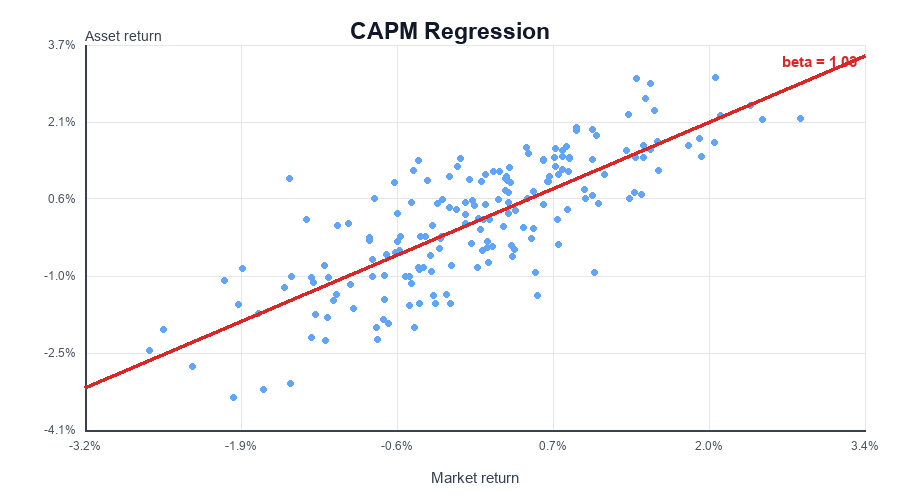


## 6.3 Joining Asset and Market Data by Date

CAPM requires aligned observations. An inner join retains only dates available in both the stock and market datasets.


### Structured Review

- **Data source:** Record where the observations come from and whether the example is online, local, or simulated.
- **Cleaning:** Inspect missing values, data types, date order, and duplicated observations before calculating returns.
- **Transformation:** Use adjacent prices for one-period returns and compounding for multi-period returns.
- **Storage:** Choose CSV for portability and pickle only for trusted Python workflows that need preserved data types.

### Formula and Workflow

1. Sort observations by date.
2. Clean the price series without inventing unsupported returns.
3. Calculate simple or log returns.
4. Aggregate with products of growth factors or sums of log returns.
5. Validate one observation manually.

### Exam Focus

- Complete `P_t / P_(t-1) - 1`, `log(P_t/P_(t-1))`, and `prod(1+R)-1`.
- Distinguish price filling from return filling.
- Explain why averaging daily returns is not the exact monthly return.

### Common Mistakes

- Calculating returns on unsorted dates.
- Keeping the first missing return in a statistical test.
- Treating a percentage value as if it were already a decimal.


In [3]:
'''
本单元用日期字典演示 inner join，避免网络和文件依赖。
只有同时出现在股票和市场数据中的日期才进入回归样本。
'''
stock_returns = {
    "2026-01-02": 0.010,
    "2026-01-05": -0.004,
    "2026-01-06": 0.006,
}
market_returns = {
    "2026-01-02": 0.007,
    "2026-01-06": 0.003,
    "2026-01-07": -0.002,
}

# 集合交集找到两个数据源共有的交易日
common_dates = sorted(set(stock_returns) & set(market_returns))

# 按相同日期顺序构造对齐样本
joined = [(date, stock_returns[date], market_returns[date]) for date in common_dates]

print("Common dates =", common_dates)
print("Joined observations =", joined)


Common dates = ['2026-01-02', '2026-01-06']
Joined observations = [('2026-01-02', 0.01, 0.007), ('2026-01-06', 0.006, 0.003)]


**Result interpretation.** January 5 and January 7 are removed because each appears in only one source.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 6.4 Testing Whether Beta Differs from Zero

A t-statistic divides the estimated beta minus its null value by its standard error. Reject $H_0:\beta=0$ when the two-sided p-value is below alpha.


### Structured Review

- **Dependent variable:** Asset return or asset excess return belongs on the left-hand side.
- **Independent variable:** Market return or market excess return explains the asset.
- **Intercept:** A constant column is required when alpha is estimated.
- **Alignment:** Join datasets by matching dates before running the regression.

### Interpretation

- `alpha` measures the intercept or abnormal return.
- `beta` measures sensitivity to the market factor.
- `R-squared` measures the proportion of sample variation explained by the model.
- A p-value evaluates statistical significance, not economic size.

### Exam Focus

- Preserve the order `x = market`, `y = stock`.
- Add a constant before OLS.
- Read the beta from the market coefficient, not the intercept.

### Common Mistakes

- Reversing stock and market inputs in `linregress`.
- Merging unmatched dates without checking missing values.
- Treating a high beta as proof of a high realized return.


In [4]:
'''
本单元从 OLS 残差计算 beta 标准误、t 值和双侧 p 值。
自由度等于样本量减去估计参数个数。
'''
import numpy as np
from scipy import stats

rng = np.random.default_rng(607)
x = rng.normal(0, 0.01, 180)
y = 0.0001 + 1.10 * x + rng.normal(0, 0.009, 180)
X = np.column_stack([np.ones(len(x)), x])
coefficients = np.linalg.lstsq(X, y, rcond=None)[0]
residuals = y - X @ coefficients

# 残差方差 = SSE / (n-k)
degrees_of_freedom = len(y) - X.shape[1]
residual_variance = np.sum(residuals**2) / degrees_of_freedom

# 系数协方差矩阵 = 残差方差 × (X'X)^(-1)
coefficient_covariance = residual_variance * np.linalg.inv(X.T @ X)
beta_standard_error = np.sqrt(coefficient_covariance[1, 1])

# t 值 = (估计 beta - 原假设 beta) / 标准误
t_value = coefficients[1] / beta_standard_error
p_value = 2 * (1 - stats.t.cdf(abs(t_value), degrees_of_freedom))

print("Estimated beta =", round(float(coefficients[1]), 4))
print("t-value =", round(float(t_value), 4))
print("p-value =", round(float(p_value), 8))
print("Decision =", "Reject H0" if p_value < 0.05 else "Do not reject H0")


Estimated beta = 1.026
t-value = 17.363
p-value = 0.0
Decision = Reject H0


**Result interpretation.** A small p-value indicates that market exposure is statistically different from zero.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 6.5 Rolling Beta and Portfolio Beta

Rolling or subperiod beta reveals time variation. Portfolio beta is the value-weighted average of component betas.


### Structured Review

- **Dependent variable:** Asset return or asset excess return belongs on the left-hand side.
- **Independent variable:** Market return or market excess return explains the asset.
- **Intercept:** A constant column is required when alpha is estimated.
- **Alignment:** Join datasets by matching dates before running the regression.

### Interpretation

- `alpha` measures the intercept or abnormal return.
- `beta` measures sensitivity to the market factor.
- `R-squared` measures the proportion of sample variation explained by the model.
- A p-value evaluates statistical significance, not economic size.

### Exam Focus

- Preserve the order `x = market`, `y = stock`.
- Add a constant before OLS.
- Read the beta from the market coefficient, not the intercept.

### Common Mistakes

- Reversing stock and market inputs in `linregress`.
- Merging unmatched dates without checking missing values.
- Treating a high beta as proof of a high realized return.


In [5]:
'''
本单元按年度分别估计 beta，并计算投资组合 beta。
每个年度都必须重新构造 X 和 y，不能直接复用全样本回归。
'''
import numpy as np

rng = np.random.default_rng(608)
years = np.repeat([2023, 2024, 2025], 120)
market = rng.normal(0.0003, 0.011, len(years))
true_yearly_betas = {2023: 0.8, 2024: 1.1, 2025: 1.4}
stock = np.array([
    true_yearly_betas[year] * market[i] + rng.normal(0, 0.008)
    for i, year in enumerate(years)
])

estimated_betas = {}
for year in np.unique(years):
    # 布尔掩码选出当前年度的股票和市场收益率
    mask = years == year
    X = np.column_stack([np.ones(mask.sum()), market[mask]])
    estimated_betas[int(year)] = np.linalg.lstsq(X, stock[mask], rcond=None)[0][1]

component_betas = np.array([0.8, 1.2, 1.5])
weights = np.array([0.25, 0.50, 0.25])

# 投资组合 beta = 各资产权重与 beta 的点积
portfolio_beta = weights @ component_betas

print("Annual betas =", {k: round(float(v), 3) for k, v in estimated_betas.items()})
print("Portfolio beta =", round(float(portfolio_beta), 3))


Annual betas = {2023: 0.667, 2024: 1.052, 2025: 1.409}
Portfolio beta = 1.175


**Result interpretation.** The annual estimates track changing systematic risk, while the portfolio beta summarizes current weighted exposure.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

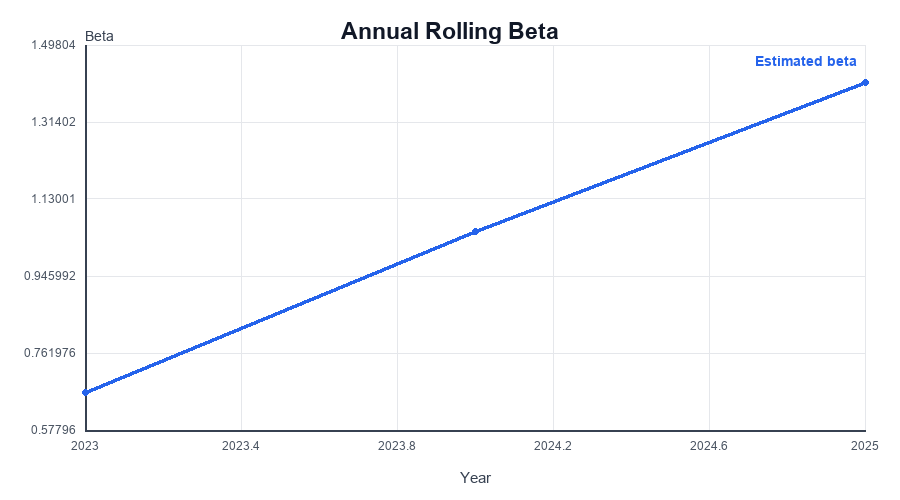


## 6.6 Alternative Regression and Join Methods


The classroom script compares `scipy.stats.linregress` with OLS and demonstrates
left, right, inner, and outer joins. These are different interfaces to recurring
data-analysis tasks.



### Structured Review

- **Dependent variable:** Asset return or asset excess return belongs on the left-hand side.
- **Independent variable:** Market return or market excess return explains the asset.
- **Intercept:** A constant column is required when alpha is estimated.
- **Alignment:** Join datasets by matching dates before running the regression.

### Interpretation

- `alpha` measures the intercept or abnormal return.
- `beta` measures sensitivity to the market factor.
- `R-squared` measures the proportion of sample variation explained by the model.
- A p-value evaluates statistical significance, not economic size.

### Exam Focus

- Preserve the order `x = market`, `y = stock`.
- Add a constant before OLS.
- Read the beta from the market coefficient, not the intercept.

### Common Mistakes

- Reversing stock and market inputs in `linregress`.
- Merging unmatched dates without checking missing values.
- Treating a high beta as proof of a high realized return.


In [6]:
'''
本单元补充 linregress 与四种连接方式。
回归参数顺序必须是 linregress(x, y)，斜率才表示 x 对 y 的解释。
'''
from scipy import stats

market = [0.055, -0.090, -0.041, 0.045, 0.022]
stock = [0.065, 0.0265, -0.0593, -0.001, 0.0345]

# x 放市场收益，y 放股票收益
regression = stats.linregress(market, stock)
print("linregress alpha =", round(regression.intercept, 4))
print("linregress beta =", round(regression.slope, 4))
print("R-squared =", round(regression.rvalue**2, 4))

left = {"foo": 1, "bar": 2}
right = {"foo": 3, "baz": 4}

# inner 只保留双方共有键
inner_keys = sorted(set(left) & set(right))

# left 保留左表全部键；right 保留右表全部键；outer 取并集
left_keys = sorted(left)
right_keys = sorted(right)
outer_keys = sorted(set(left) | set(right))

print("Inner keys =", inner_keys)
print("Left keys =", left_keys)
print("Right keys =", right_keys)
print("Outer keys =", outer_keys)


linregress alpha = 0.0137
linregress beta = 0.2911
R-squared = 0.1478
Inner keys = ['foo']
Left keys = ['bar', 'foo']
Right keys = ['baz', 'foo']
Outer keys = ['bar', 'baz', 'foo']


**Result interpretation.** The regression slope is CAPM beta when market return is the independent variable. Join type determines which unmatched observations survive.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.
